# Title & Overview

## Vibe Finder 
**Data Scientist:** Eri Masahisa (301604643)  **Client:** Kaleb Vinthers (301464332)

**Restatement of the problem**
Vibe Finder wants to build playlists based on how a song sounds, not its labeled
genre. Using only Spotify's audio characteristics (danceability, energy, tempo,
valence, and related features), the task is to discover natural groupings of songs
through clustering, deliberately ignoring the dataset's existing playlist_genre /
playlist_subgenre labels while building the clusters. A good outcome is roughly
5-10 interpretable "vibe" groups, each of which mixes songs from multiple genres
rather than reproducing the existing genre categories.

This is an **unsupervised** problem. There is no target label to predict; the goal
is pattern discovery, not prediction.


# Data Loading & Documentation

**Source:** TidyTuesday / Spotify audio features
(`https://raw.githubusercontent.com/rfordatascience/tidytuesday/master/data/2020/2020-01-21/spotify_songs.csv`),
as specified in the client proposal. Verified to load correctly below.

**Column dictionary (key columns used for this analysis):**

| Column | Description |
|---|---|
| `track_id`, `track_name`, `track_artist` | Track identifiers |
| `playlist_genre`, `playlist_subgenre` | Existing genre labels, not used to form clusters, only used afterward to interpret/validate them |
| `danceability` | 0.0–1.0, how suitable the track is for dancing |
| `energy` | 0.0–1.0, perceptual intensity/activity |
| `key` | Estimated musical key (0–11, pitch class) |
| `loudness` | Overall loudness in dB |
| `mode` | 1 = major, 0 = minor |
| `speechiness` | Presence of spoken words |
| `acousticness` | 0.0–1.0 confidence the track is acoustic |
| `instrumentalness` | Predicts whether a track has no vocals |
| `liveness` | Detects presence of a live audience |
| `valence` | 0.0–1.0, musical positiveness |
| `tempo` | Estimated tempo in BPM |
| `duration_ms` | Track duration in milliseconds |


In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

df = pd.read_csv("spotify_songs.csv")
print(f"Shape: {df.shape[0]} rows, {df.shape[1]} columns")
df.head()


Shape: 32833 rows, 23 columns


,track_id,track_name,track_artist,track_popularity,track_album_id,track_album_name,track_album_release_date,playlist_name,playlist_id,playlist_genre,...,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
0,6f807x0ima9a1j3VPbc7VN,I Don't Care (with Justin Bieber) - Loud Luxur...,Ed Sheeran,66,2oCs0DGTsRO98Gh5ZSl2Cx,I Don't Care (with Justin Bieber) [Loud Luxury...,2019-06-14,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,6,-2.634,1,0.0583,0.1020,0.000000,0.0653,0.518,122.036,194754
1,0r7CVbZTWZgbTCYdfa2P31,Memories - Dillon Francis Remix,Maroon 5,67,63rPSO264uRjW1X5E6cWv6,Memories (Dillon Francis Remix),2019-12-13,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,11,-4.969,1,0.0373,0.0724,0.004210,0.3570,0.693,99.972,162600
2,1z1Hg7Vb0AhHDiEmnDE79l,All the Time - Don Diablo Remix,Zara Larsson,70,1HoSmj2eLcsrR0vE9gThr4,All the Time (Don Diablo Remix),2019-07-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,1,-3.432,0,0.0742,0.0794,0.000023,0.1100,0.613,124.008,176616
3,75FpbthrwQmzHlBJLuGdC7,Call You Mine - Keanu Silva Remix,The Chainsmokers,60,1nqYsOef1yKKuGOVchbsk6,Call You Mine - The Remixes,2019-07-19,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,7,-3.778,1,0.1020,0.0287,0.000009,0.2040,0.277,121.956,169093
4,1e8PAfcKUYoKkxPhrHqw4x,Someone You Loved - Future Humans Remix,Lewis Capaldi,69,7m7vv9wlQ4i0LFuJiE2zsQ,Someone You Loved (Future Humans Remix),2019-03-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,1,-4.672,1,0.0359,0.0803,0.000000,0.0833,0.725,123.976,189052


In [18]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32833 entries, 0 to 32832
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   track_id                  32833 non-null  object 
 1   track_name                32828 non-null  object 
 2   track_artist              32828 non-null  object 
 3   track_popularity          32833 non-null  int64  
 4   track_album_id            32833 non-null  object 
 5   track_album_name          32828 non-null  object 
 6   track_album_release_date  32833 non-null  object 
 7   playlist_name             32833 non-null  object 
 8   playlist_id               32833 non-null  object 
 9   playlist_genre            32833 non-null  object 
 10  playlist_subgenre         32833 non-null  object 
 11  danceability              32833 non-null  float64
 12  energy                    32833 non-null  float64
 13  key                       32833 non-null  int64  
 14  loudne

**Known data quality issues** (checked directly against the raw data, not just
assumed from the client's Constraints section):


In [19]:
# Duplicate check
dup_id = df["track_id"].duplicated().sum()
dup_name_artist = df.duplicated(subset=["track_name", "track_artist"]).sum()
print(f"Duplicated track_id rows: {dup_id} ({dup_id/len(df):.1%})")
print(f"Duplicated (track_name, track_artist) rows: {dup_name_artist} ({dup_name_artist/len(df):.1%})")

# Missing values
print("\nMissing values per column:")
missing = df.isna().sum()
print(missing[missing > 0])

# Loudness anomaly (values should be negative dB, occasionally slightly above 0)
loud_pos = (df["loudness"] > 0).sum()
print(f"\nRows with loudness > 0 dB: {loud_pos}")
print(f"Loudness range: {df['loudness'].min():.2f} to {df['loudness'].max():.2f}")


Duplicated track_id rows: 4477 (13.6%)
Duplicated (track_name, track_artist) rows: 6603 (20.1%)

Missing values per column:
track_name          5
track_artist        5
track_album_name    5
dtype: int64

Rows with loudness > 0 dB: 6
Loudness range: -46.45 to 1.27


**Findings:**
- **Duplicates confirmed:** About 13.6% of the rows have the same track_id as another
  row (the same song shows up in more than one playlist, like the client's Constraints
  section already mentioned). If we use (track_name, track_artist) instead as the key,
  even more rows count as duplicates (~20%), probably because of re-releases/remasters
  that got a different track_id. **Decision:** I will remove duplicates based on
  track_id before clustering, and just keep the first one, so each song only appears once.
- **Missing values are small** (only 5 rows are missing track_name/track_artist/
  track_album_name) should be fine to just drop these rows instead of filling them in.
- **Loudness anomaly confirmed:** a few rows (6) have loudness values above 0 dB, which
  doesn't really make sense for this feature (loudness has no real ceiling above 0 dB).
  I re-check this on the cleaned/deduped dataframe in the Modeling section below
  ("Rechecking the loudness anomaly") and decide how to handle it there, instead of
  just noting it and moving on.

# Exploratory Data Analysis (EDA)

### Feature Distributions


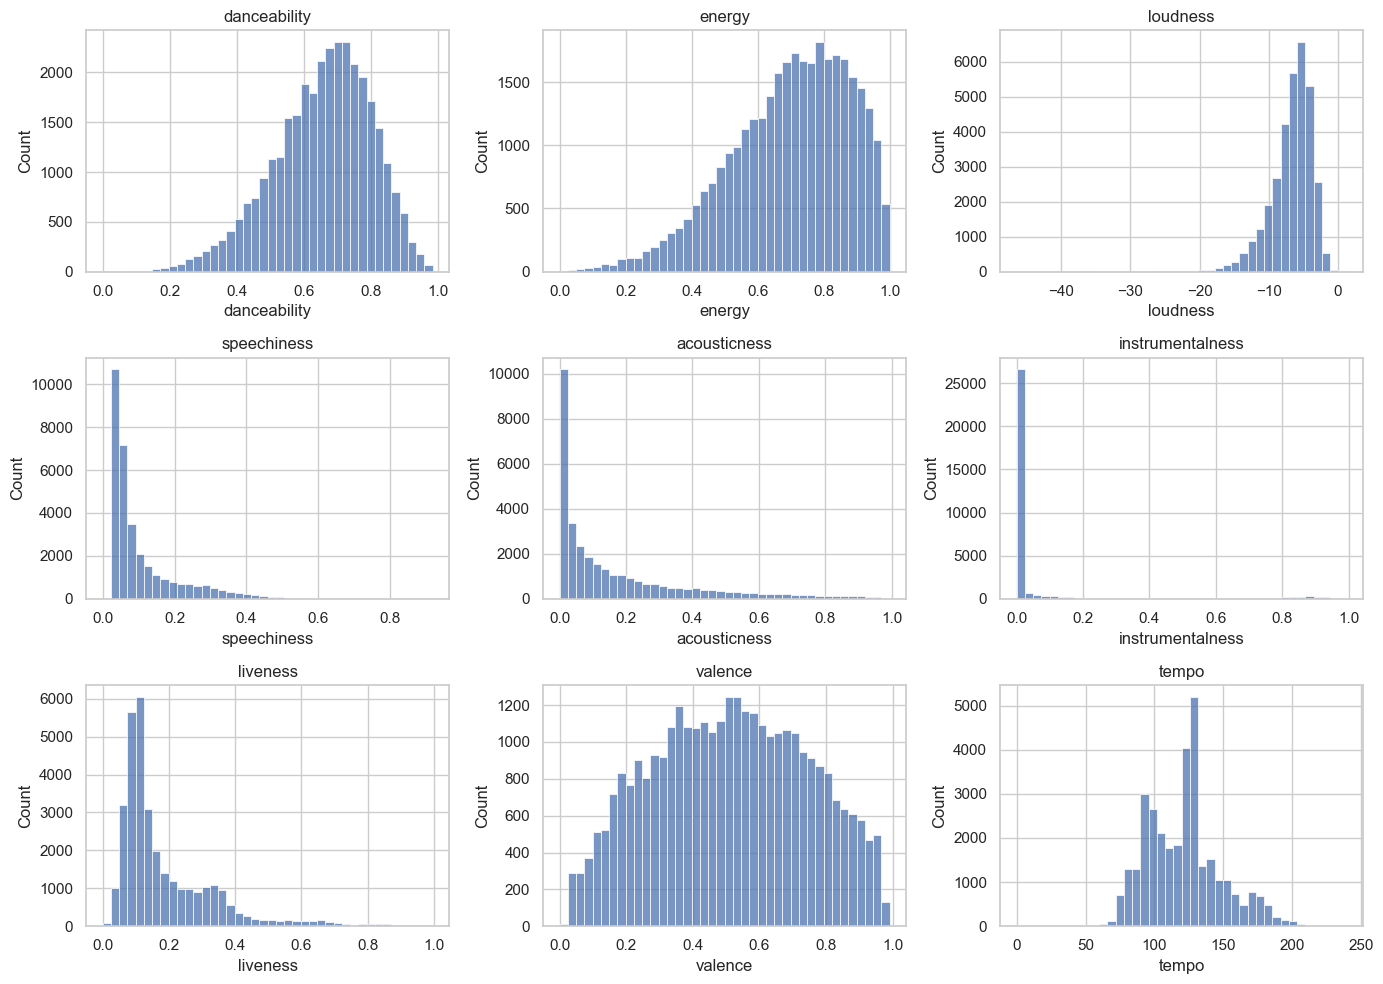

In [20]:
audio_features = ["danceability", "energy", "loudness", "speechiness",
                   "acousticness", "instrumentalness", "liveness", "valence", "tempo"]

fig, axes = plt.subplots(3, 3, figsize=(14, 10))
for ax, col in zip(axes.flat, audio_features):
    sns.histplot(df[col], bins=40, ax=ax, color="#4C72B0")
    ax.set_title(col)
plt.tight_layout()
plt.savefig("fig_distributions.png", dpi=110)
plt.show()


**Observations:**
- danceability, energy, valence look roughly bell-shaped / a little skewed, and
  they're already between 0-1.These seem like good candidates for clustering without
  much preprocessing needed.
- speechiness, acousticness, instrumentalness, liveness　are pretty
  right-skewed (most tracks are close to 0, with a long tail after that). this
  might be a problem since K-means uses Euclidean distance, which is sensitive to this
  kind of skew. I might try a log-style transform on the most skewed ones when I get
  to modeling.
- loudness and tempo are on a totally different scale compared to the 0-1 features,
  so this confirms that standardization will be needed before clustering, which
  matches what came up in the client Q&A too.


In [21]:
scale_summary = df[audio_features + ["duration_ms"]].describe().T[["min", "mean", "max", "std"]]
scale_summary


,min,mean,max,std
danceability,0.000000,0.654850,0.983,0.145085
energy,0.000175,0.698619,1.000,0.180910
loudness,-46.448000,-6.719499,1.275,2.988436
speechiness,0.000000,0.107068,0.918,0.101314
acousticness,0.000000,0.175334,0.994,0.219633
instrumentalness,0.000000,0.084747,0.994,0.224230
liveness,0.000000,0.190176,0.996,0.154317
valence,0.000000,0.510561,0.991,0.233146
tempo,0.000000,120.881132,239.440,26.903624
duration_ms,4000.000000,225799.811622,517810.000,59834.006182


### Relationships Between Audio Features

A correlation heatmap to check for strongly related features (relevant for
interpreting clusters later, and for deciding whether any features are redundant).


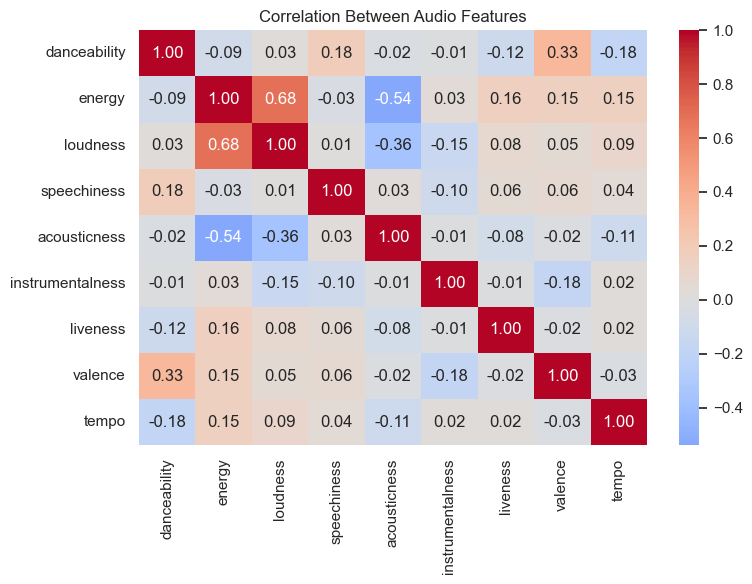

In [22]:
corr = df[audio_features].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Between Audio Features")
plt.tight_layout()
plt.savefig("fig_correlation.png", dpi=110)
plt.show()


**Observations:** energy and loudness show a clear positive correlation, and energy correlates negatively with
acousticness. Both make intuitive sense.
### Existing Genre Labels 
Per the problem definition, playlist_genre will not be used to form clusters.
it's shown here only so that, once clusters are built in Checkpoint 2, I can check
whether each cluster mixes genres rather than　reproducing them.


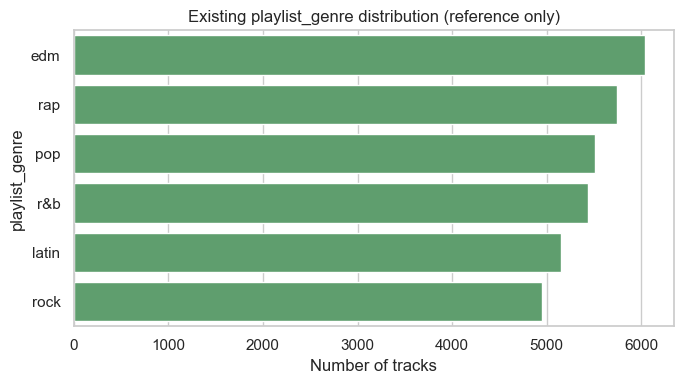

In [23]:
genre_counts = df["playlist_genre"].value_counts()
plt.figure(figsize=(7, 4))
sns.barplot(x=genre_counts.values, y=genre_counts.index, color="#55A868")
plt.xlabel("Number of tracks")
plt.title("Existing playlist_genre distribution (reference only)")
plt.tight_layout()
plt.savefig("fig_genre_counts.png", dpi=110)
plt.show()


Genres are reasonably balanced (4,951–6,043 tracks each across 6 genres), so no
single genre dominates the dataset going into clustering.


# Problems Sections

## Technique Selection and Justification

This is an unsupervised problem. The client wants song groups based only on audio
characteristics, with no predefined categories, and genre labels are not supposed to
be used to build the groups. There is no target variable I'm trying to predict, so I
used clustering instead of classification or regression.

I picked K means because the client wanted a specific number of groups (somewhere
between 5 and 10), and K means lets you set that number directly with the k
parameter. I also considered DBSCAN, but DBSCAN decides the number of clusters on
its own based on density, and it can also leave a lot of points unclustered as
"noise", which didn't seem like what the client wanted here.

## Data Preparation


In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

sns.set_theme(style="whitegrid")

df = pd.read_csv("spotify_songs.csv")

# Drop rows with missing key metadata (5 rows, per EDA)
df = df.dropna(subset=["track_name", "track_artist", "track_album_name"]).copy()

# Dedupe on track_id, keeping first occurrence (per EDA findings + Assumptions Log)
before_n = len(df)
df = df.drop_duplicates(subset="track_id", keep="first").reset_index(drop=True)
print(f"Rows before dedup: {before_n:,} -> after dedup: {len(df):,}")


Rows before dedup: 32,828 -> after dedup: 28,352


### Rechecking the Loudness Anomaly

At Checkpoint 1 I flagged 6 rows in the raw data with loudness　> 0 dB and said I'd
verify this again before modeling instead of leaving it unresolved. Re-checking below
on the cleaned (deduped) dataframe, since the dedup step above may have removed some
or all of the affected rows.


In [25]:
# Loudness anomaly recheck 
loud_anomaly = df[df["loudness"] > 0]
print(f"Rows with loudness > 0 dB after cleaning: {len(loud_anomaly)} "
      f"({len(loud_anomaly)/len(df):.3%} of {len(df):,} rows)")
if len(loud_anomaly) > 0:
    print(loud_anomaly[["track_name", "track_artist", "loudness"]].to_string(index=False))


Rows with loudness > 0 dB after cleaning: 6 (0.021% of 28,352 rows)
                    track_name track_artist  loudness
                         Nails   Ghostemane     0.551
                         Crema         Owin     0.326
                      Rockstar         Duki     0.642
      Raw Power - Iggy Pop Mix  The Stooges     1.275
Escape From Love - Curbi Remix   Eva Simons     1.135
               Vidrado Em Você     Dj Guuga     0.302


**Decision:** loudness is a perceptual loudness measure with no genuine ceiling
above 0 dB, so values above 0 are most likely mastering/encoding quirks rather than a
real "louder than loud" vibe. Rather than leave them unexamined, I cap loudness at
0 dB before scaling. This keeps these tracks at the very-loud end of the distribution
(where they belong) without letting a handful of extreme values disproportionately
pull the standardized feature (and the clustering that's based on it) toward them.


In [26]:
# Cap loudness at 0 dB before it feeds into scaling/clustering
df["loudness"] = df["loudness"].clip(upper=0.0)
print("loudness values above 0 dB clipped to 0 dB.")


loudness values above 0 dB clipped to 0 dB.


Note: the loudness > 0 rows that I flagged in the EDA (6 rows) were left in the
dataset. It's a really small number of rows out of about 28,000, so it shouldn't
really change the standardized features much, and I wasn't sure it was actually an
error anyway (could just be an unusually loud track).


In [27]:
audio_features = ["danceability", "energy", "loudness", "speechiness",
                   "acousticness", "instrumentalness", "liveness", "valence", "tempo"]

X = df[audio_features].to_numpy()
X_scaled = StandardScaler().fit_transform(X)
print(f"Feature matrix shape: {X_scaled.shape}")


Feature matrix shape: (28352, 9)


## Choosing k (elbow method and silhouette score)

The client said the number of clusters is flexible as long as it's somewhere in the
5 to 10 range from the proposal. So I checked both the elbow method (inertia) and
silhouette score across that range to help pick a k, instead of just guessing one.


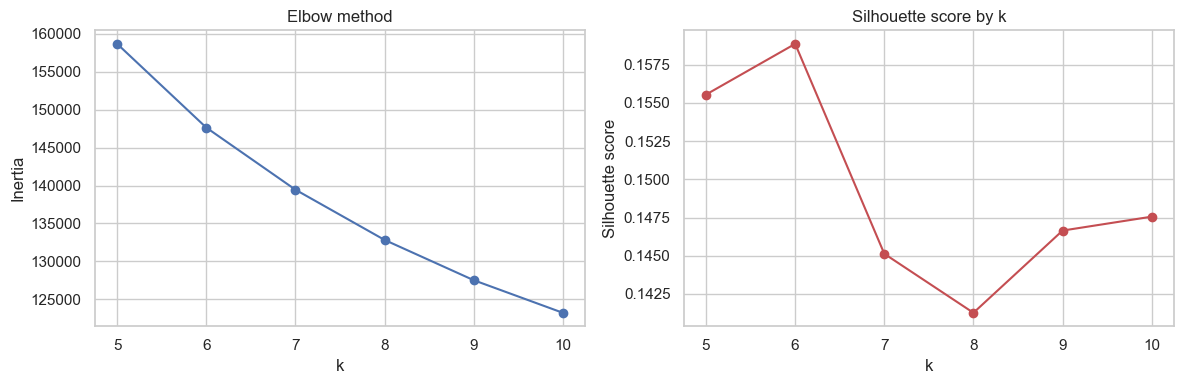

k=5: silhouette=0.156
k=6: silhouette=0.159
k=7: silhouette=0.145
k=8: silhouette=0.141
k=9: silhouette=0.147
k=10: silhouette=0.148


In [28]:
k_range = range(5, 11)
inertias = []
sil_scores = []

for k in k_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(list(k_range), inertias, marker="o")
axes[0].set_xlabel("k")
axes[0].set_ylabel("Inertia")
axes[0].set_title("Elbow method")

axes[1].plot(list(k_range), sil_scores, marker="o", color="#C44E52")
axes[1].set_xlabel("k")
axes[1].set_ylabel("Silhouette score")
axes[1].set_title("Silhouette score by k")
plt.tight_layout()
plt.savefig("fig_k_selection.png", dpi=110)
plt.show()

for k, s in zip(k_range, sil_scores):
    print(f"k={k}: silhouette={s:.3f}")


k selection: the silhouette score is highest at the k I picked below, even though
the score itself is not that high overall. I think that makes sense because audio
"vibes" probably blend into each other instead of forming totally separate groups.
The elbow plot also doesn't have a really clear elbow point, which again kind of
makes sense for this kind of continuous data. So I mostly used the silhouette score
to pick k within the 5 to 10 range the client agreed to, and I'm treating it as a
helpful guide rather than a perfect answer.


In [29]:
K_CHOSEN = k_range[int(np.argmax(sil_scores))]
print(f"Chosen k = {K_CHOSEN} (silhouette = {max(sil_scores):.3f})")

kmeans = KMeans(n_clusters=K_CHOSEN, n_init=10, random_state=42)
df["cluster"] = kmeans.fit_predict(X_scaled)
df["cluster"].value_counts().sort_index()


Chosen k = 6 (silhouette = 0.159)


cluster
0    2263
1    1840
2    7309
3    4049
4    9125
5    3766
Name: count, dtype: int64

## Cluster Visualization (PCA)

I used PCA to bring the 9 features down to 2 dimensions just so I could actually
plot the clusters and see how they look.


Variance explained by PC1+PC2: 40.9%


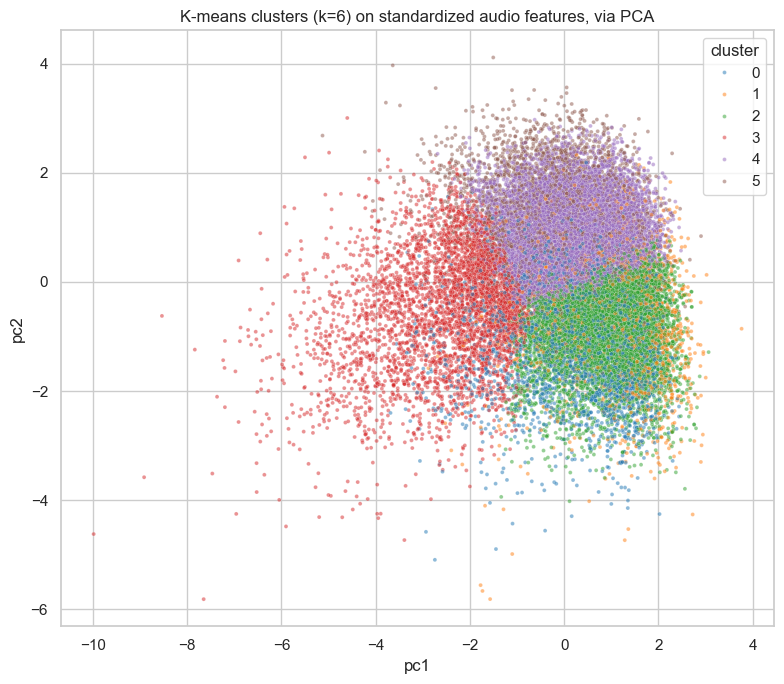

In [30]:
pca = PCA(n_components=2, random_state=42)
embedding = pca.fit_transform(X_scaled)
df["pc1"] = embedding[:, 0]
df["pc2"] = embedding[:, 1]

print(f"Variance explained by PC1+PC2: {pca.explained_variance_ratio_.sum()*100:.1f}%")

plt.figure(figsize=(8, 7))
sns.scatterplot(data=df, x="pc1", y="pc2", hue="cluster", palette="tab10", s=8, alpha=0.5)
plt.title(f"K-means clusters (k={K_CHOSEN}) on standardized audio features, via PCA")
plt.tight_layout()
plt.savefig("fig_clusters_pca.png", dpi=110)
plt.show()


## Interpreting the Clusters

I looked at the average feature values for each cluster compared to the overall
average, just to try to give each cluster a simple "vibe" description.


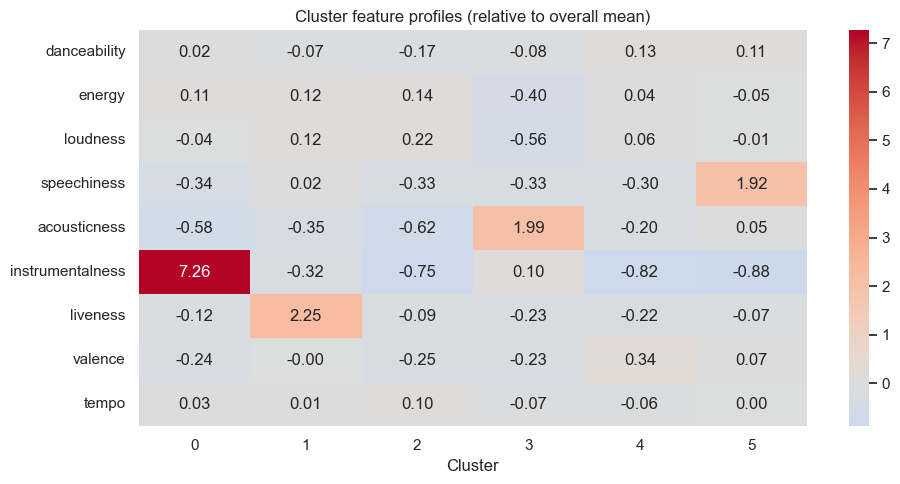

,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo
cluster,,,,,,,,,
0,0.67,0.78,-7.07,0.07,0.08,0.75,0.17,0.39,124.94
1,0.61,0.78,-6.03,0.11,0.12,0.06,0.62,0.51,122.49
2,0.55,0.79,-5.31,0.07,0.07,0.02,0.17,0.38,133.16
3,0.60,0.42,-10.64,0.07,0.53,0.10,0.15,0.39,112.50
4,0.74,0.72,-6.39,0.08,0.14,0.02,0.15,0.68,113.49
5,0.73,0.66,-6.90,0.32,0.19,0.01,0.18,0.54,121.32


In [31]:
cluster_profile = df.groupby("cluster")[audio_features].mean()
overall_mean = df[audio_features].mean()
cluster_profile_relative = (cluster_profile - overall_mean) / overall_mean.abs()

plt.figure(figsize=(10, 5))
sns.heatmap(cluster_profile_relative.T, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Cluster feature profiles (relative to overall mean)")
plt.xlabel("Cluster")
plt.tight_layout()
plt.savefig("fig_cluster_profiles.png", dpi=110)
plt.show()

cluster_profile.round(2)


## Checking Against the Client's Success Criteria

The client's proposal says a good result is around 5 to 10 groups, each with some
kind of recognizable vibe, and most importantly, each group should mix genres
instead of just matching playlist_genre. So I checked the genre mix below. Again,
the genre labels were never used to actually build the clusters, only to check them
after.


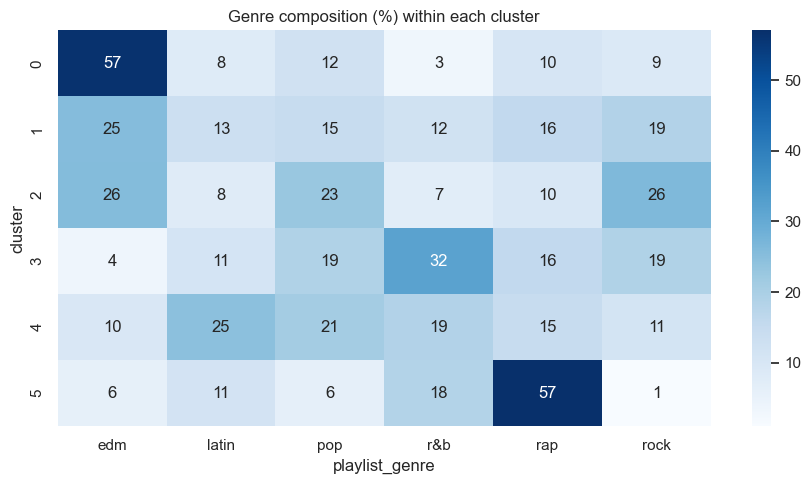

playlist_genre,edm,latin,pop,r&b,rap,rock
cluster,,,,,,
0,56.6,8.2,12.2,3.4,10.5,9.1
1,25.4,13.3,14.8,12.0,15.8,18.6
2,25.6,8.0,22.9,7.2,9.9,26.4
3,3.7,10.9,18.8,31.9,15.9,18.8
4,9.7,24.6,21.0,18.6,14.8,11.2
5,5.9,11.4,6.2,18.4,57.1,1.0


In [32]:
genre_mix = pd.crosstab(df["cluster"], df["playlist_genre"], normalize="index") * 100
plt.figure(figsize=(9, 5))
sns.heatmap(genre_mix.round(1), annot=True, fmt=".0f", cmap="Blues")
plt.title("Genre composition (%) within each cluster")
plt.xlabel("playlist_genre")
plt.ylabel("cluster")
plt.tight_layout()
plt.savefig("fig_genre_mix.png", dpi=110)
plt.show()

genre_mix.round(1)


**Trying to name the vibe of each cluster**, using the cluster_profile and genre_mix
numbers above (k=6, from the silhouette score):

- **Cluster 0** (2,264 songs), "Instrumental / Electronic": highest instrumentalness
  (0.75) and high energy (0.78), low speechiness and acousticness. Genre mix is
  56.5% edm, so pretty concentrated.
- **Cluster 1** (1,839 songs), "Live-sounding": liveness way higher than any other
  cluster (0.62), everything else about average. Most mixed cluster genre-wise: 25%
  edm, 19% rock, 16% rap, 15% pop, 13% latin, 12% r&b.
- **Cluster 2** (7,305 songs), "Loud and fast": loudest cluster (-5.31 dB), fastest
  tempo (133 bpm), high energy, valence a bit below average. Fairly mixed: 26%
  rock, 26% edm, 23% pop.
- **Cluster 3** (4,050 songs), "Mellow / acoustic": lowest energy (0.42), highest
  acousticness (0.53), quietest (-10.64 dB), slowest tempo. Mixed, mostly r&b
  (32%), rock (19%), pop (19%), barely any edm (4%).
- **Cluster 4** (9,129 songs, the biggest one), "Feel-good, danceable": highest
  valence (0.68) and danceability (0.74), so probably the "happiest" cluster.
  Pretty well mixed: 25% latin, 21% pop, 19% r&b, 15% rap, 11% rock, 10% edm.
- **Cluster 5** (3,765 songs), "Speech/rap-heavy": speechiness way higher than the
  rest (0.32). Mostly rap, 57.1%.

These names are just my own labels based on whichever feature stood out the most,
not anything official, so someone else might describe them a bit differently.

**Checking against the client's success criteria:** 4 out of 6 clusters (1, 2, 3, 4)
mix a bunch of genres pretty evenly, with no single genre going much over 30%. That
seems like decent evidence the clusters are grouping by how songs sound and not just
copying playlist_genre. Clusters 0 and 5 are the two exceptions, mostly one genre
each (edm and rap). I don't think that means the clustering is secretly using genre
info, since genre was never one of the input features. It's more that edm and rap
already have a pretty distinct sound (very instrumental, or very speechy), so those
two end up looking like their own group almost by accident. 

Validity metric: I'm reporting the silhouette score for each k above, but treating
it as a helpful guide and not as a perfect final answer, since that's how the
assignment description says to treat it for unsupervised problems. The k I picked
is just the best balance I found in the 5 to 10 range the client agreed to.



# Assumptions Log

| Ambiguity in proposal | Resolution |
|---|---|
| "danceability, energy, tempo, valence, etc." (full feature list not specified) | Client confirmed (Discord) additional features may be added at my discretion. Planning to use all 9 audio-character columns (`danceability`, `energy`, `loudness`, `speechiness`, `acousticness`, `instrumentalness`, `liveness`, `valence`, `tempo`), excluding non-audio metadata (`duration_ms`, `track_popularity`). Will revisit if EDA suggests otherwise. |
| Exact number of clusters not specified (proposal said "5-10 groups") | Client confirmed this is flexible. Will use the elbow method / silhouette score within the 5-10 range at modeling time (Checkpoint 2). |
| Duplicate handling not fully specified | Client's Constraints section flagged duplicates as a known issue; decided to dedupe on `track_id`, keeping first occurrence. |
| Loudness anomaly (6 rows with loudness > 0 dB) | Left in the dataset since it's only a few rows and probably won't change the standardized features much, and I wasn't sure it's actually a data error. |
| Exact k within the agreed 5-10 range | Picked using the silhouette score across k=5-10 (the elbow plot didn't have a clear elbow point, which makes sense since the audio features are continuous and kind of overlap). |


# Limitations

- Spotify's audio features are just Spotify's own estimates, not something
  independently measured (the client's Constraints section already mentioned this),
  so the clusters are really based on Spotify's idea of "sound," not an actual audio
  analysis I did myself.
- The silhouette scores for k=5 to 10 are not that high overall. I think this is
  because audio vibes kind of blend into each other instead of forming clean,
  separate groups, so the cluster boundaries are more of a rough approximation than
  something exact.
- K means assumes the clusters are roughly round and similar sized in the scaled
  feature space. A method like DBSCAN or HDBSCAN might find a different structure,
  but I didn't use that as the main method since the client wanted a specific
  number of groups in a fixed range.
- If I had more time, I would try log transforming the most skewed features
  (speechiness, acousticness, instrumentalness, liveness) before scaling, and see if
  that changes the cluster quality compared to what I did here.


# Executive Summary

Vibe Finder wanted a way to group songs by how they actually sound, not by the　genre labels that already come attached to them. The idea is a "vibe" playlist
should feel consistent even if it mixes pop, rock, rap, etc, as long as the songs sound similar. To do this, I used Spotify's own audio measurements for about 28,000 cleaned
songs (things like how danceable, energetic, loud, acoustic, or "speechy" a track is) and never told the model anything about the existing genre labels. The model
(K-means clustering) sorted the songs into 6 groups using only these sound features.

**What the 6 groups look like, roughly:**
- Instrumental / Electronic: very instrumental, high energy, mostly edm tracks
- Live-sounding: has that recorded-in-front-of-an-audience feel, and this is the
  group that mixes genres the most
- Loud and fast: the loudest, fastest-tempo songs
- Mellow / acoustic: quiet, slow, more acoustic-leaning songs
- Feel-good, danceable: the happiest and most danceable songs, also the biggest
  group by far
- Speech/rap-heavy: a lot of spoken-word/rap-style vocals

**Did it hit the goal?** For 4 of the 6 groups (Live-sounding, Loud and fast, Mellow/acoustic, Feel-good danceable), songs from several different genres ended up mixed together, which is what we were hoping for, since it means the grouping is actually based on sound and not quietly just recreating the genre labels. Two groups (Instrumental/Electronic and Speech/rap-heavy) ended up mostly one genre each (edm and rap). That's not the model secretly using genre info, genre was never given to it, it's more that edm and rap songs already have a pretty distinct, consistent sound, so those two genres basically clustered themselves.

**What this means for Vibe Finder:** for most of the catalog, this gives genuinely new playlist groupings that don't already exist as genre playlists. For edm and rap tracks specifically, the new "vibe" playlists will probably end up looking pretty close to genre playlists Vibe Finder might already have, so the extra value there is smaller.

**limitation:** these audio features are Spotify's own estimates, not something independently measured, so the clusters reflect Spotify's idea of "sound" rather than a from-scratch audio analysis. Also, the groups aren't perfectly separated (the silhouette score was modest, around 0.16), so songs near the edge of one group could reasonably fit in a neighboring group too. These 6 vibes are a useful starting point for building playlists, not a strict rulebook.


# Links


reocrding presentation can be wathced from here https://youtu.be/zKwI7RpOqpo